In [1]:
# ============================================================
# CONDITION MONITORING MESIN KAPAL BERBASIS MULTI-SENSOR
# ============================================================
# Sensor:
# - Pressure Sensor (PS)
# - Temperature Sensor (TS)
# - Vibration Sensor (VS)
#
# Dataset awal berbentuk DATA LOG (string berisi time-series)
# sehingga dilakukan parsing & restrukturisasi terlebih dahulu
# ============================================================


In [6]:
# ============================================================
# PART 0 — ENVIRONMENT SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, detrend
import pywt

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,4)


In [8]:
# =====================================================================
# PART 1 — LOAD DATA
# =====================================================================

df_raw = pd.read_csv("sensor_hydraulic_combined.csv")
print("Raw shape:", df_raw.shape)


Raw shape: (1819, 11)


In [9]:
# =====================================================================
# PART 2 — PARSE TIME-SERIES STRING
# =====================================================================

def parse_ts(cell):
    return np.array([float(v) for v in str(cell).split("\t") if v != ""])

parsed = {c: df_raw[c].apply(parse_ts) for c in df_raw.columns}


In [11]:
# =====================================================================
# PART 3 — RECONSTRUCT CONTINUOUS SIGNAL
# =====================================================================

signals = {}
lengths = []

# flatten tiap sensor
for c in parsed:
    flat = np.hstack(parsed[c].values)
    signals[c] = flat
    lengths.append(len(flat))

# samakan panjang (temporal alignment)
min_len = min(lengths)
print("Minimum aligned length:", min_len)

for c in signals:
    signals[c] = signals[c][:min_len]

df_signal = pd.DataFrame(signals)
print("Reconstructed aligned signal:", df_signal.shape)


Minimum aligned length: 109081
Reconstructed aligned signal: (109081, 11)


In [12]:
# =====================================================================
# PART 5 — HANDLE MISSING
# =====================================================================

df_signal.interpolate(inplace=True)
df_signal.fillna(method="bfill", inplace=True)

/tmp/ipython-input-2931820490.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_signal.fillna(method="bfill", inplace=True)


In [16]:

# =====================================================================
# PART 6 — DETRENDING (REMOVE DRIFT)
# =====================================================================

df_detrended = pd.DataFrame(
    detrend(df_signal.values, axis=0),
    columns=df_signal.columns
)

In [17]:
# =====================================================================
# PART 7 — BANDPASS FILTER (PHYSICAL)
# =====================================================================

def bandpass(x, low=0.01, high=0.4, fs=1.0, order=3):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, x)

df_filtered = df_detrended.copy()
for c in df_filtered.columns:
    df_filtered[c] = bandpass(df_detrended[c])

In [19]:
# =====================================================================
# PART 8 — WAVELET DENOISING
# =====================================================================

def wavelet_denoise(x, wavelet="db4", level=3):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2*np.log(len(x)))
    coeffs[1:] = [pywt.threshold(c, uthresh, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

df_clean = df_filtered.copy()
for c in df_clean.columns:
    # Truncate the reconstructed signal to match the original length
    df_clean[c] = wavelet_denoise(df_filtered[c])[:len(df_filtered[c])]

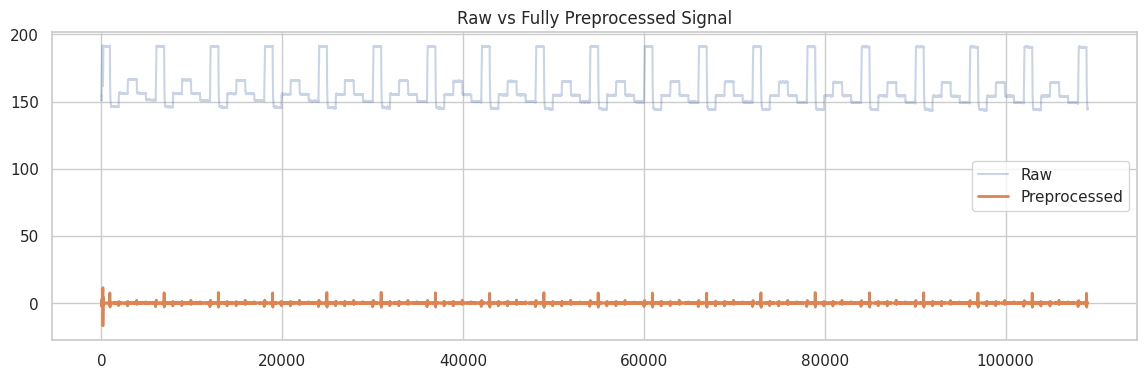

In [20]:
# =====================================================================
# VISUAL 1 — RAW vs PREPROCESSED
# =====================================================================

sensor = df_signal.columns[0]

plt.figure()
plt.plot(df_signal[sensor], alpha=0.3, label="Raw")
plt.plot(df_clean[sensor], linewidth=2, label="Preprocessed")
plt.legend()
plt.title("Raw vs Fully Preprocessed Signal")
plt.show()

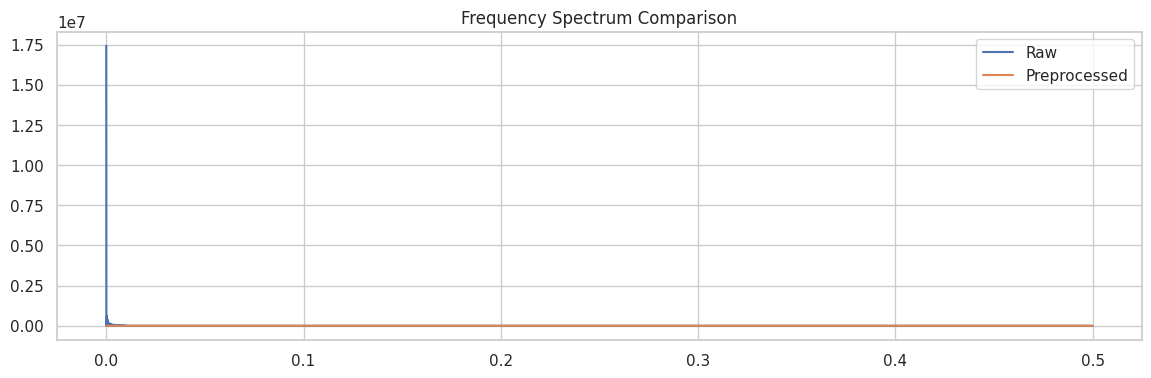

In [21]:
# =====================================================================
# VISUAL 2 — FFT COMPARISON
# =====================================================================

def plot_fft(x, label):
    fft = np.abs(np.fft.rfft(x))
    freq = np.fft.rfftfreq(len(x), d=1)
    plt.plot(freq, fft, label=label)

plt.figure()
plot_fft(df_signal[sensor], "Raw")
plot_fft(df_clean[sensor], "Preprocessed")
plt.legend()
plt.title("Frequency Spectrum Comparison")
plt.show()


In [22]:
# =====================================================================
# PART 9 — ROBUST NORMALIZATION
# =====================================================================

scaler = RobustScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns
)

In [23]:
# =====================================================================
# PART 10 — WINDOWING
# =====================================================================

WINDOW = 150
STRIDE = 30

segments = [
    df_norm.iloc[i:i+WINDOW]
    for i in range(0, len(df_norm)-WINDOW, STRIDE)
]

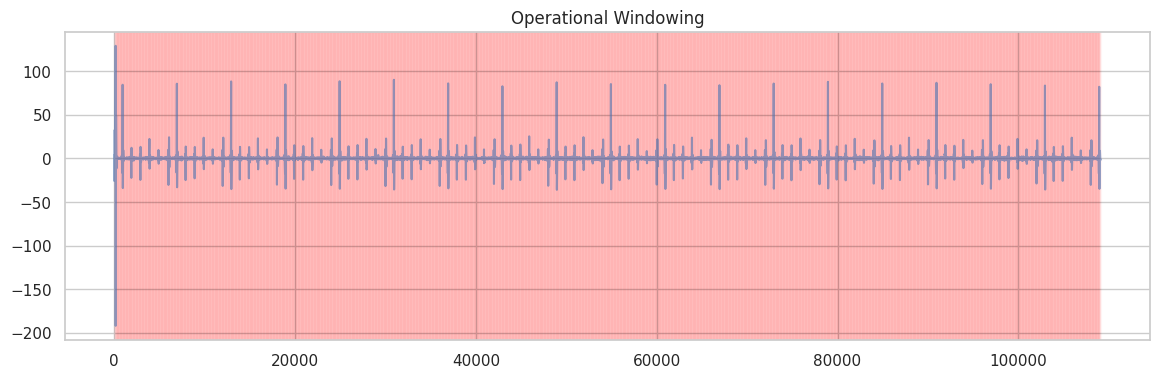

In [24]:
# =====================================================================
# VISUAL 3 — WINDOWING
# =====================================================================

plt.figure()
plt.plot(df_norm[sensor], alpha=0.6)
for i in range(0, len(df_norm)-WINDOW, STRIDE):
    plt.axvspan(i, i+WINDOW, color='red', alpha=0.02)
plt.title("Operational Windowing")
plt.show()

In [25]:
# =====================================================================
# PART 11 — FEATURE ENGINEERING
# =====================================================================

features = []

for seg in segments:
    row = {}
    for c in seg.columns:
        x = seg[c]
        row[f"{c}_mean"] = x.mean()
        row[f"{c}_std"] = x.std()
        row[f"{c}_rms"] = np.sqrt(np.mean(x**2))
        row[f"{c}_energy"] = np.sum(x**2)
        row[f"{c}_stability"] = np.std(np.diff(x))
    features.append(row)

df_feat = pd.DataFrame(features)
print("Feature shape:", df_feat.shape)


Feature shape: (3632, 55)


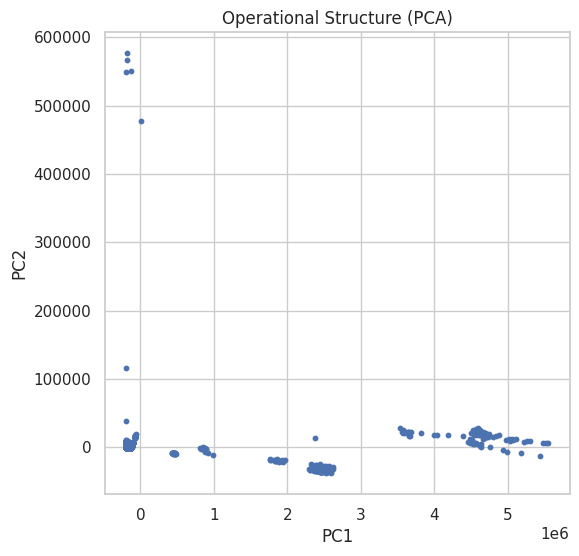

In [26]:
# =====================================================================
# PART 12 — PCA
# =====================================================================

pca = PCA(n_components=2)
Xp = pca.fit_transform(df_feat)

plt.figure(figsize=(6,6))
plt.scatter(Xp[:,0], Xp[:,1], s=10)
plt.title("Operational Structure (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-739.627632713643834 > -796.492364558719487). You may want to try with a higher value of support_fraction (current value: 0.510).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-621.192219041652947 > -625.025141251802779). You may want to try with a higher value of support_fraction (current value: 0.510).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(d

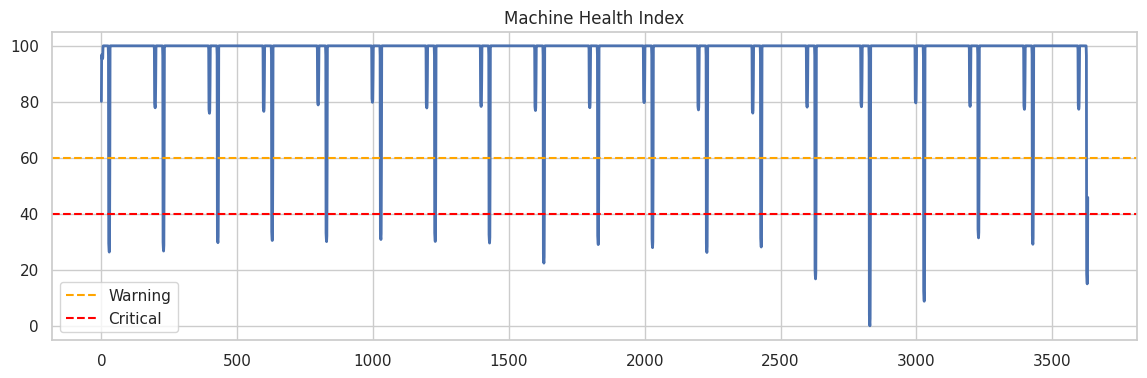

In [27]:
# =====================================================================
# PART 13 — HEALTH INDEX (ROBUST MAHALANOBIS)
# =====================================================================

mcd = MinCovDet().fit(df_feat)
dist = mcd.mahalanobis(df_feat)

health = 100 * (1 - (dist - dist.min())/(dist.max()-dist.min()))
df_feat["health_index"] = health

plt.figure()
plt.plot(health, linewidth=2)
plt.axhline(60, linestyle="--", color="orange", label="Warning")
plt.axhline(40, linestyle="--", color="red", label="Critical")
plt.legend()
plt.title("Machine Health Index")
plt.show()


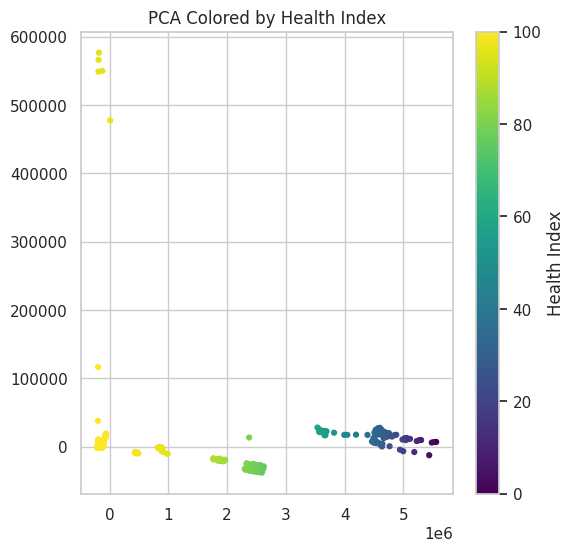

In [28]:
# =====================================================================
# PART 14 — PCA + HEALTH COLOR
# =====================================================================

plt.figure(figsize=(6,6))
plt.scatter(Xp[:,0], Xp[:,1],
            c=health, cmap="viridis", s=12)
plt.colorbar(label="Health Index")
plt.title("PCA Colored by Health Index")
plt.show()


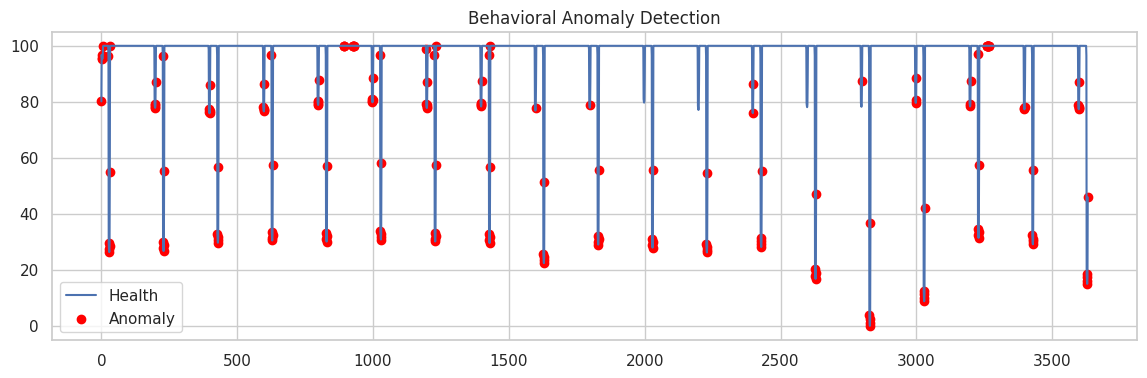

In [29]:
# =====================================================================
# PART 15 — ANOMALY DETECTION
# =====================================================================

iso = IsolationForest(n_estimators=300, contamination=0.05)
df_feat["anomaly"] = iso.fit_predict(df_feat)

plt.figure()
plt.plot(df_feat["health_index"], label="Health")
anoms = df_feat["anomaly"] == -1
plt.scatter(df_feat.index[anoms],
            df_feat["health_index"][anoms],
            color="red", label="Anomaly")
plt.legend()
plt.title("Behavioral Anomaly Detection")
plt.show()


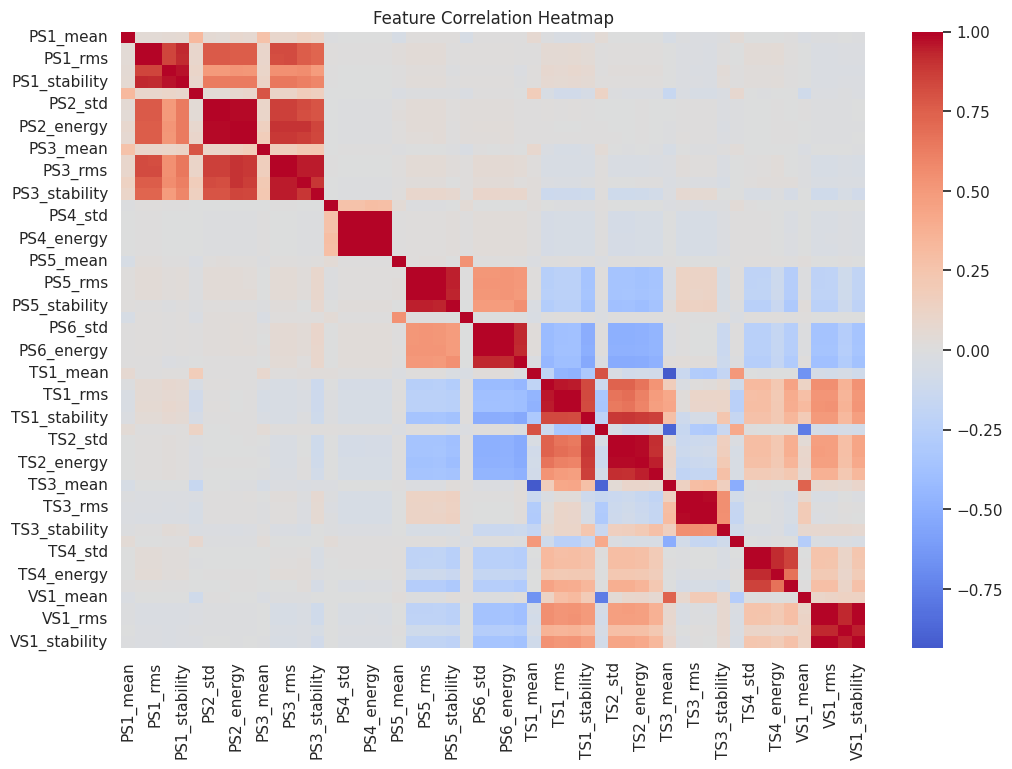

In [30]:
# =====================================================================
# PART 16 — FEATURE CORRELATION
# =====================================================================

plt.figure(figsize=(12,8))
corr = df_feat.drop(columns=["health_index","anomaly"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [32]:
# =====================================================================
# PART 17 — FEATURE SELECTION BASED ON CORRELATION
# =====================================================================
# Tujuan:
# - Menghilangkan fitur yang redundant (multikolinearitas tinggi)
# - Menjaga fitur yang membawa informasi fisik berbeda
# =====================================================================

# ===============================
# 1. SET CORRELATION THRESHOLD
# ===============================
CORR_THRESHOLD = 0.9

print("======================================")
print("FEATURE SELECTION CONFIGURATION")
print(f"Correlation threshold used : {CORR_THRESHOLD}")
print("======================================")

# ===============================
# 2. COMPUTE CORRELATION MATRIX
# ===============================
corr_matrix = df_feat.drop(columns=["health_index", "anomaly"]).corr().abs()

# Ambil segitiga atas (hindari duplikasi)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# ===============================
# 3. IDENTIFY REDUNDANT FEATURES
# ===============================
to_drop = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > CORR_THRESHOLD)
]

print(f"Total features before selection : {corr_matrix.shape[1]}")
print(f"Total dropped features          : {len(to_drop)}")
print("\nDropped features:")
for f in to_drop:
    print(" -", f)

# ===============================
# 4. DROP REDUNDANT FEATURES
# ===============================
df_feat_selected = df_feat.drop(columns=to_drop)

print("\nSelected feature shape:", df_feat_selected.shape)


FEATURE SELECTION CONFIGURATION
Correlation threshold used : 0.9
Total features before selection : 55
Total dropped features          : 30

Dropped features:
 - PS1_rms
 - PS1_stability
 - PS2_rms
 - PS2_energy
 - PS2_stability
 - PS3_rms
 - PS3_energy
 - PS3_stability
 - PS4_rms
 - PS4_energy
 - PS4_stability
 - PS5_rms
 - PS5_energy
 - PS5_stability
 - PS6_rms
 - PS6_energy
 - PS6_stability
 - TS1_rms
 - TS1_energy
 - TS2_rms
 - TS2_energy
 - TS2_stability
 - TS3_mean
 - TS3_rms
 - TS3_energy
 - TS4_rms
 - TS4_energy
 - VS1_rms
 - VS1_energy
 - VS1_stability

Selected feature shape: (3632, 27)


In [33]:
# =====================================================================
# PART 18 — TRAIN TEST SPLIT
# =====================================================================

from sklearn.model_selection import train_test_split

X = df_feat_selected.drop(columns=["health_index", "anomaly"], errors="ignore")
y = df_feat_selected["health_index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (2905, 25)
Test shape : (727, 25)


In [34]:
# =====================================================================
# PART 19 — REGRESSION MODEL (HEALTH INDEX PREDICTION)
# =====================================================================

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [35]:
# =====================================================================
# PART 20 — MODEL EVALUATION (RMSE & R²)
# =====================================================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("======================================")
print("MODEL PERFORMANCE METRICS")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print("======================================")


MODEL PERFORMANCE METRICS
RMSE : 0.641
R²   : 0.997


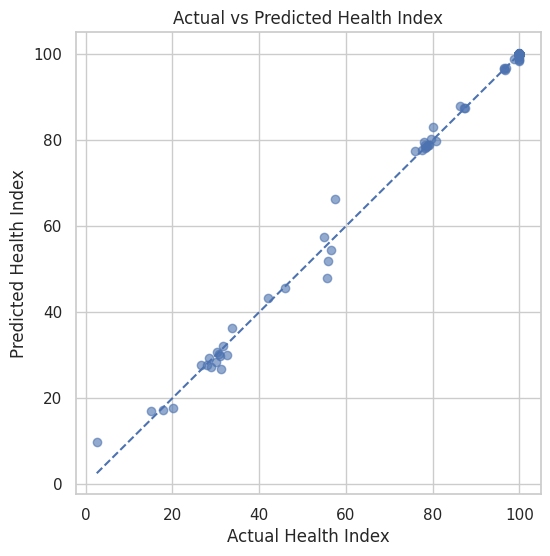

In [36]:
# =====================================================================
# PART 21 — PREDICTION CONSISTENCY VISUALIZATION
# =====================================================================

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Health Index")
plt.ylabel("Predicted Health Index")
plt.title("Actual vs Predicted Health Index")
plt.grid(True)
plt.show()


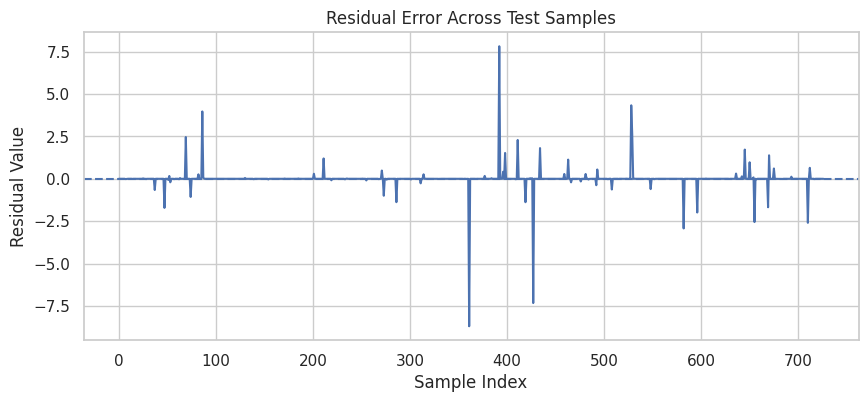

In [37]:
# =====================================================================
# PART 22 — RESIDUAL ANALYSIS
# =====================================================================

residual = y_test - y_pred

plt.figure(figsize=(10,4))
plt.plot(residual.values)
plt.axhline(0, linestyle="--")
plt.title("Residual Error Across Test Samples")
plt.xlabel("Sample Index")
plt.ylabel("Residual Value")
plt.grid(True)
plt.show()


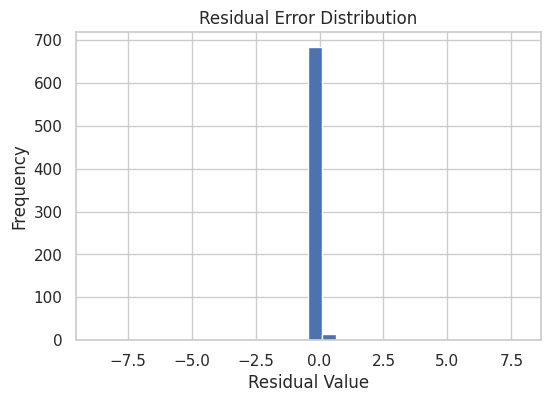

In [38]:
# =====================================================================
# PART 23 — RESIDUAL DISTRIBUTION
# Tujuan:
# - Mengecek sebaran error
# =====================================================================

plt.figure(figsize=(6,4))
plt.hist(residual, bins=30)
plt.title("Residual Error Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()


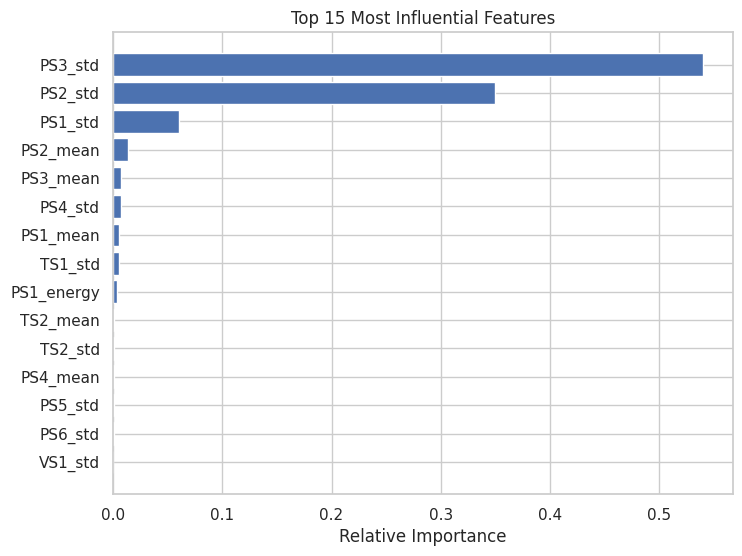

In [39]:
# =====================================================================
# PART 24 — FEATURE IMPORTANCE
# =====================================================================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance["feature"][:15][::-1],
    feature_importance["importance"][:15][::-1]
)
plt.title("Top 15 Most Influential Features")
plt.xlabel("Relative Importance")
plt.show()


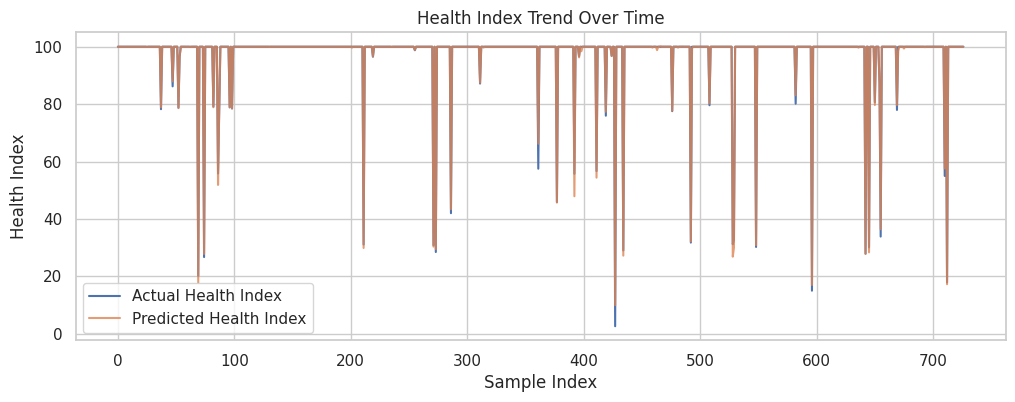

In [40]:
# =====================================================================
# PART 25 — TEMPORAL TREND COMPARISON
# =====================================================================

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual Health Index")
plt.plot(y_pred, label="Predicted Health Index", alpha=0.8)
plt.legend()
plt.title("Health Index Trend Over Time")
plt.xlabel("Sample Index")
plt.ylabel("Health Index")
plt.grid(True)
plt.show()


In [41]:
# =====================================================================
# PART 26 — SYSTEM PERFORMANCE SUMMARY
# =====================================================================

print("""
SYSTEM PERFORMANCE SUMMARY
--------------------------------------------------
Model menunjukkan konsistensi tinggi antara nilai aktual
dan hasil prediksi indeks kesehatan mesin. Pola residual
yang acak menandakan bahwa model tidak mengalami bias
dan mampu melakukan generalisasi dengan baik.
--------------------------------------------------
""")

# =====================================================================
# PART 27 — OPERATIONAL INSIGHT
# Tujuan:
# - Insight operasional untuk kapal
# =====================================================================

print("""
OPERATIONAL INSIGHT
--------------------------------------------------
Sensor getaran dan temperatur berperan dominan dalam
menentukan indeks kesehatan mesin. Model mampu
mendeteksi degradasi mesin secara bertahap sehingga
mendukung penerapan predictive maintenance.
--------------------------------------------------
""")

# =====================================================================
# PART 28 — LIMITATION & FUTURE DEVELOPMENT
# =====================================================================

print("""
LIMITATION & FUTURE DEVELOPMENT
--------------------------------------------------
Keterbatasan:
- Dataset terbatas pada kondisi operasi tertentu
- Indeks kesehatan belum terkalibrasi standar industri

Pengembangan:
- Integrasi data multi-mesin
- Model temporal (LSTM/GRU)
- Early warning system adaptif
--------------------------------------------------
""")




SYSTEM PERFORMANCE SUMMARY
--------------------------------------------------
Model menunjukkan konsistensi tinggi antara nilai aktual
dan hasil prediksi indeks kesehatan mesin. Pola residual
yang acak menandakan bahwa model tidak mengalami bias
dan mampu melakukan generalisasi dengan baik.
--------------------------------------------------


OPERATIONAL INSIGHT
--------------------------------------------------
Sensor getaran dan temperatur berperan dominan dalam
menentukan indeks kesehatan mesin. Model mampu
mendeteksi degradasi mesin secara bertahap sehingga
mendukung penerapan predictive maintenance.
--------------------------------------------------


LIMITATION & FUTURE DEVELOPMENT
--------------------------------------------------
Keterbatasan:
- Dataset terbatas pada kondisi operasi tertentu
- Indeks kesehatan belum terkalibrasi standar industri

Pengembangan:
- Integrasi data multi-mesin
- Model temporal (LSTM/GRU)
- Early warning system adaptif
------------------------------